# Importación

In [383]:
!pip install xgboost

In [384]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from plotly.subplots import make_subplots
from scipy.stats import yeojohnson
from scipy.stats import normaltest
import plotly.graph_objects as go
from plotly.offline import iplot
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import boxcox
import plotly.express as px
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import numpy as np
from datetime import datetime
import holidays
import torch

# Lectura de datos

In [385]:
data_path = "gripe.csv"

df = pd.read_csv(data_path)
# Renombro la columna para tener más claro a qué hace referencia
df = df.rename(columns={'week': 'date'})
# Ordeno según la fecha
df = df.sort_values(by='date')
# Reorganizo los indices
df = df.reset_index(drop=True)
# Quito la columna que contenía los indices
df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,Id,date,region_code,region_name,TauxGrippe
0,14701,2004-01-11,26,BOURGOGNE,154.0
1,14679,2004-01-18,26,BOURGOGNE,237.0
2,14657,2004-01-25,26,BOURGOGNE,23.0
3,14635,2004-02-01,26,BOURGOGNE,44.0
4,14613,2004-02-08,26,BOURGOGNE,65.0


In [386]:
porcentaje_ceros = (df["TauxGrippe"] == 0).mean() * 100

print(f"Porcentaje de ceros: {porcentaje_ceros:.2f}%")

Porcentaje de ceros: 41.54%


# Busco NAN para quitarlos.

In [387]:
print("NaNs:", df['TauxGrippe'].isna().sum())

NaNs: 3


Para sustituir los 3 valores nulos, hago una interpolación usando la media de tasa de gripe del valor anterior y el siguiente. Hago esta sustitución ya que creo que es la más moderada de las 3 posibles y no avanza ni retrocede la serie. Aunque siendo tan pocos valores nulos no creo que afectara mucho la opción escogida.

In [388]:
df["TauxGrippe"] = df["TauxGrippe"].interpolate(method="linear")

In [389]:
missing_values_mask = df.isnull()

fig = px.imshow(missing_values_mask.T,
                labels=dict(x="Time Index", y="Variables", color="Missing Values"),
                x=df.index,
                y=df.columns,
                color_continuous_scale=[[0, 'green'], [1, 'white']])

fig.update_layout(title="Valores nulos",
                  xaxis_title="",
                  yaxis_title="Variables",
                  xaxis_showgrid=True, yaxis_showgrid=True)

fig.show()

Veo que ya no hay valores nulos.

# Visualización de los datos

In [390]:
def plot_dataset(df, title):
    data = []

    value = go.Scatter(
        x=df.index,
        y=df.value,
        mode="lines",
        name="values",
        marker=dict(),
        text=df.index,
        line=dict(color="rgba(0,0,0, 0.3)"),
    )
    data.append(value)

    layout = dict(
        title=title,
        xaxis=dict(title="Date", ticklen=5, zeroline=False),
        yaxis=dict(title="Number of passengers", ticklen=5, zeroline=False),
    )

    fig = dict(data=data, layout=layout)
    iplot(fig)

In [391]:
df = df.set_index(['date'])
df = df.rename(columns={'TauxGrippe': 'value'})

df.index = pd.to_datetime(df.index)
if not df.index.is_monotonic_increasing:
    df = df.sort_index()

plot_dataset(df, title='AirPassengers: Número de pasajeros por cada mes')

Observo que la serie no tiene tendencia y que parece tener una estacionalidad que se repite en los meses de frío, sobretodo en febrero. Además, observo que el pico más grande está en 2009 y que en los siguientes años no se vuelven a producir picos tan altos como en los anteriores. Esto puede deberse a las campañas de vacunación.

De todas formas, compruebo la estacionalidad con test de hipótesis.

In [392]:
X = df['value'].values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.749848
p-value: 0.000000
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570


Según el resultado obtenido, puedo rechazar la hipótesis nula y decir que la serie es estacionaria y por lo tanto no necesito diferenciarla.

## División en las diversas componentes

Ahora descompongo en sus diversas componentes.

In [393]:
def decomposition_plot(
        ts_index, observed=None, seasonal=None, trend=None, resid=None
    ):
        """Plots the decomposition output
        """
        series = []
        if observed is not None:
            series += ["Original"]
        if trend is not None:
            series += ["Trend"]
        if seasonal is not None:
            series += ["Seasonal"]
        if resid is not None:
            series += ["Residual"]
        if len(series) == 0:
            raise ValueError(
                "All component flags were off. Need atleast one of the flags turned on to plot."
            )
        fig = make_subplots(
            rows=len(series), cols=1, shared_xaxes=True, subplot_titles=series
        )
        x = ts_index
        row = 1
        if observed is not None:
            fig.append_trace(
                go.Scatter(x=x, y=observed, name="Original"), row=row, col=1
            )
            row += 1
        if trend is not None:
            fig.append_trace(
                go.Scatter(x=x, y=trend, name="Trend"), row=row, col=1
            )
            row += 1
        if seasonal is not None:
            fig.append_trace(
                go.Scatter(x=x, y=seasonal, name="Seasonal"),
                row=row,
                col=1,
            )
            row += 1
        if resid is not None:
            fig.append_trace(
                go.Scatter(x=x, y=resid, name="Residual"), row=row, col=1
            )
            row += 1

        fig.update_layout(
            title_text="Seasonal Decomposition",
            autosize=False,
            width=1200,
            height=700,
            title={"x": 0.5, "xanchor": "center", "yanchor": "top"},
            titlefont={"size": 20},
            legend_title=None,
            showlegend=False,
            legend=dict(
                font=dict(size=15),
                orientation="h",
                yanchor="bottom",
                y=0.98,
                xanchor="right",
                x=1,
            ),
            yaxis=dict(
                titlefont=dict(size=15),
                tickfont=dict(size=15),
            ),
            xaxis=dict(
                titlefont=dict(size=15),
                tickfont=dict(size=15),
            )
        )
        return fig

In [394]:
# Pongo period con valor 52 porque en un año hay 52 semanas, si fueran mensuales los datos pondría 12
res = seasonal_decompose(df.value, period=52, model="additive", extrapolate_trend="freq")

In [395]:
fig = decomposition_plot(df.index, res.observed, res.seasonal, res.trend, res.resid)
fig.show()

Por todo lo que he ido observando, veo que tiene una estacionalidad fuerte que se repite anualmente y cuyo pico siempre está en los meses fríos, lo que tiene sentido al estar hablando de la gripe.

# Preprocesamiento de los datos

Antes ya eliminé los valores nulos, así que eso ya no hace falta. Ahora voy a escalar los datos ya que como se pide usar tanto ML como DL lo veo como necesario para hacer que todos los datos tengan el mismo impacto en el modelo.

## Analizo la distribución.

In [396]:
fig = px.histogram(df['value'],
                   nbins=50,
                   title="Tasa de gripe")
fig.show()

Veo que no tiene distribución normal si no que más bien sigue una distribución sesgada con cola hacia la derecha. Esto se debe a la cantidad de 0s que hay.

In [397]:
# Hago esto para ayudar a interpretar a los modelos
df['grippe_presence'] = (df['value'] > 0).astype(int)

In [398]:
df.head()

,Id,region_code,region_name,value,grippe_presence
date,,,,,
2004-01-11,14701,26,BOURGOGNE,154.0,1
2004-01-18,14679,26,BOURGOGNE,237.0,1
2004-01-25,14657,26,BOURGOGNE,23.0,1
2004-02-01,14635,26,BOURGOGNE,44.0,1
2004-02-08,14613,26,BOURGOGNE,65.0,1


## Time delay embedding

Ahora voy a aplicar time delay embedding para transformar la serie en vectores y así tener la información en un formato que pueda ser usado para entrenar a los modelos.

In [399]:
def create_time_delay_embedding(data, horizon=1, final_lag=8, column="y", column_index=None):
    df = pd.DataFrame()
    df["y"] = data[column].copy()
    for i in range(horizon, final_lag+1):
        df["lag_{}".format(i)] = data[column].shift(i)
    if column_index is None:
        df.index = data.index
    else:
        df.index = data[column_index]
    return df

Voy a usar `Horizon` con valor 1 para predecir el valor semana a semana y voy a usar `final lag`con valor 8 para usar los 2 meses previos para la predicción.

In [400]:
horizon = 1
final_lag = 8
df_time_delay = create_time_delay_embedding(df, horizon=horizon, final_lag=final_lag, column="value")
df_time_delay = df_time_delay.dropna()

## Creo las features

Ahora añado predictores para facilitar el aprendizaje de mi modelo

In [401]:
df_features = (
                df_time_delay
                .assign(day = df_time_delay.index.day)
                .assign(month = df_time_delay.index.month)
                .assign(day_of_week = df_time_delay.index.dayofweek)
              )

In [402]:
us_holidays = holidays.US()

def is_holiday(date):
    return 1 if (date in us_holidays) else 0

def add_holiday_col(df):
    return df.assign(is_holiday = df.index.to_series().apply(is_holiday))


df_features = add_holiday_col(df_features)
df_features

,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,day,month,day_of_week,is_holiday
date,,,,,,,,,,,,,
2004-03-07,66.0,20.0,49.0,45.0,65.0,44.0,23.0,237.0,154.0,7,3,6,0
2004-03-14,89.0,66.0,20.0,49.0,45.0,65.0,44.0,23.0,237.0,14,3,6,0
2004-03-21,6.0,89.0,66.0,20.0,49.0,45.0,65.0,44.0,23.0,21,3,6,0
2004-03-28,0.0,6.0,89.0,66.0,20.0,49.0,45.0,65.0,44.0,28,3,6,0
2004-04-04,0.0,0.0,6.0,89.0,66.0,20.0,49.0,45.0,65.0,4,4,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-08,4.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,8,12,6,0
2013-12-15,0.0,4.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,15,12,6,0
2013-12-22,0.0,0.0,4.0,36.0,21.0,0.0,0.0,0.0,0.0,22,12,6,0


## Transformaciones

In [403]:
# Aplico log10 sumando 1 a las tasas de gripe
df_features['value_log'] = np.log10(df_features['y'] + 1)

df_features['value_log']

,value_log
date,
2004-03-07,1.826075
2004-03-14,1.954243
2004-03-21,0.845098
2004-03-28,0.000000
2004-04-04,0.000000
...,...
2013-12-08,0.698970
2013-12-15,0.000000
2013-12-22,0.000000


In [404]:
df_features

,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,day,month,day_of_week,is_holiday,value_log
date,,,,,,,,,,,,,,
2004-03-07,66.0,20.0,49.0,45.0,65.0,44.0,23.0,237.0,154.0,7,3,6,0,1.826075
2004-03-14,89.0,66.0,20.0,49.0,45.0,65.0,44.0,23.0,237.0,14,3,6,0,1.954243
2004-03-21,6.0,89.0,66.0,20.0,49.0,45.0,65.0,44.0,23.0,21,3,6,0,0.845098
2004-03-28,0.0,6.0,89.0,66.0,20.0,49.0,45.0,65.0,44.0,28,3,6,0,0.000000
2004-04-04,0.0,0.0,6.0,89.0,66.0,20.0,49.0,45.0,65.0,4,4,6,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-08,4.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,8,12,6,0,0.698970
2013-12-15,0.0,4.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,15,12,6,0,0.000000
2013-12-22,0.0,0.0,4.0,36.0,21.0,0.0,0.0,0.0,0.0,22,12,6,0,0.000000


### Gráfico

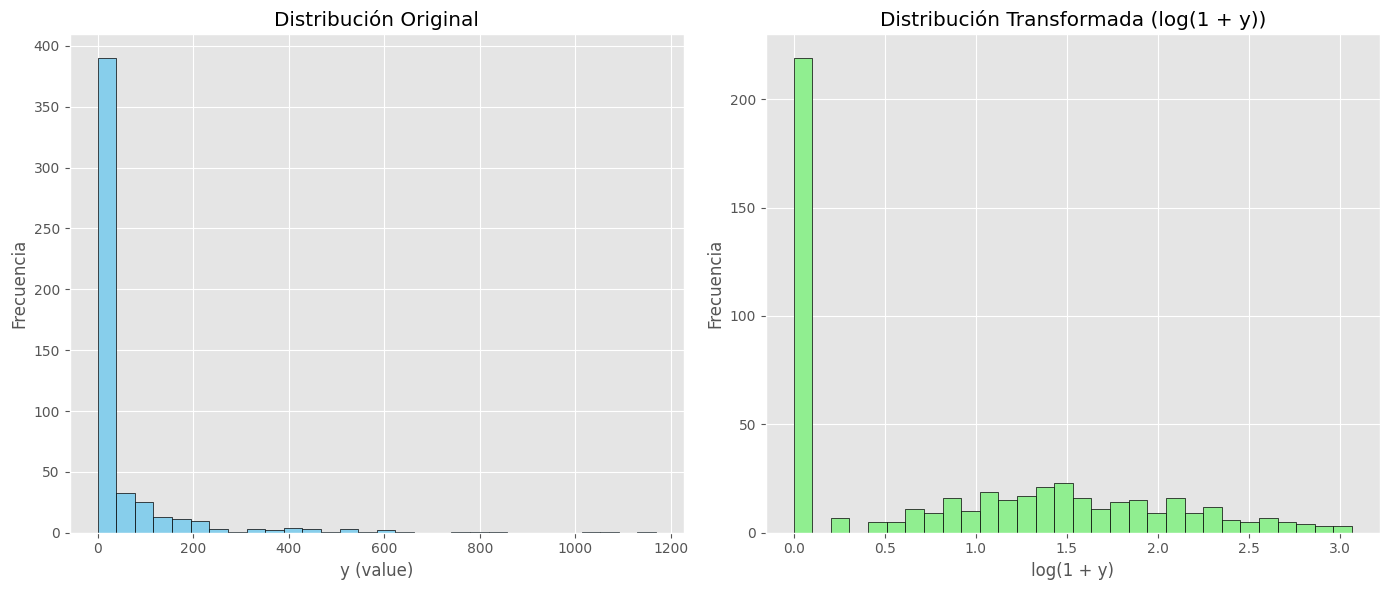

In [405]:
import matplotlib.pyplot as plt

# Antes de la transformación
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(df_features['y'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución Original')
plt.xlabel('y (value)')
plt.ylabel('Frecuencia')

# Después de la transformación
plt.subplot(1, 2, 2)
plt.hist(df_features['value_log'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribución Transformada (log(1 + y))')
plt.xlabel('log(1 + y)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Veo que con esta transformación se reduce un poco la cola.

## Divido en train y test

Funciones para dividir en conjunto de entrenamiento y test y para elegir el escalador. Además, la primera sirve para dividir la variable objetivo y las de entrada.

In [406]:
def feature_label_split(df, target_col):
    y = df[[target_col]]
    X = df.drop(columns=[target_col])
    return X, y

def train_val_test_split(df, target_col, test_ratio):
    val_ratio = test_ratio / (1 - test_ratio)
    X, y = feature_label_split(df, target_col)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_ratio, shuffle=False)
    return X_train, X_val, X_test, y_train, y_val, y_test



def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

# Uso los datos transformados en lugar de 'y'
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(df_features, 'value_log', 0.2)

## Escalado

In [407]:
scaler = get_scaler('robust')
X_train_arr = scaler.fit_transform(X_train)
X_val_arr = scaler.transform(X_val)
X_test_arr = scaler.transform(X_test)

y_train_arr = scaler.fit_transform(y_train)
y_val_arr = scaler.transform(y_val)
y_test_arr = scaler.transform(y_test)

He probado distintos scalers y estas han sido mis conclusiones:

- En un principio lo hice con `MinMaxScaler` pero las predicciones de los modelos de DL eran muy malas. Esto se debe a que los datos tienen una distribución sesgada con cola hacia la derecha y además contienen mucho ceros. Minmax creo que es afectado por estos valores extremos y comprime demasiado los datos dificultando el aprendizaje.
- Después probé `StandardScaler` y las predicciones mejoraron (ya no eran una linea recta con dos picos en el medio), pero todavía no veía que se adaptaran del todo a los patrones de los datos. Puede ser porque la media y la desviación se vieran afectadas también por la cantidad de ceros.
- Por último, probé el `RobustScaler` que escala los datos según la mediana y el rango intercuartílico y vi que mejoraban todavía más las predicciones y se adaptaban mejor a los patrones. Esto puede ser porque este escalador se suele recomendar para distribuciones sesgadas con valores extremos.

El siguiente código prepara los datos para que el modelo de inteligencia artificial pueda usarlos sin problema. Para conseguirlo, primero los convierte a un formato que el modelo entiende (tensores). Luego los junta en Datasets, que son grupos de datos con sus features y targets correspondientes. Y por último, crea “paquetes” (batches) con estos datos para que el modelo pueda aprender o hacer predicciones de forma ordenada y en partes pequeñas, en lugar de todo de golpe.

In [408]:
batch_size = 8

train_features = torch.Tensor(X_train_arr)
train_targets = torch.Tensor(y_train_arr)
val_features = torch.Tensor(X_val_arr)
val_targets = torch.Tensor(y_val_arr)
test_features = torch.Tensor(X_test_arr)
test_targets = torch.Tensor(y_test_arr)

train = TensorDataset(train_features, train_targets)
val = TensorDataset(val_features, val_targets)
test = TensorDataset(test_features, test_targets)

train_loader = DataLoader(train, batch_size=batch_size, shuffle=False, drop_last=True)
val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader_one = DataLoader(test, batch_size=1, shuffle=False, drop_last=True)

In [409]:
print("Batches en val_loader:", len(val_loader))

Batches en val_loader: 12


# Entrenamiento de modelos

## Machine Learning

Como empiezo con los modelos de ML no necesito usar todavía los tensores ni los DataLoaders. Después para DL sí los usaré.

In [410]:
# Forecast bias
def forecast_bias_aggregate(actuals, predictions):
    return 100*(np.nansum(predictions)-np.nansum(actuals))/np.nansum(actuals)
# Cambio a SMAPE porque MAPE no va bien con tantos 0s sobretodo porque podría dar infinito
def symmetric_mean_absolute_percentage_error(y_true, y_pred, epsilon=1e-10):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    # Excluir los casos donde tanto y_true como y_pred sean cero
    mask = ~((y_true == 0) & (y_pred == 0))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + epsilon

    return np.mean(numerator / denominator) * 100

# Plot model results
def plotModelResults(model, X_train, X_test, y_test, plot_intervals=False, plot_anomalies=False):

    prediction = model.predict(X_test)

    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)

    compute_metrics(y_test, prediction)
    error = symmetric_mean_absolute_percentage_error(y_test, prediction)
    plt.title("Symmetric Mean absolute percentage error {0:.2f}%".format(error))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# Evaluation metrics
def compute_metrics(y_true, y_pred):
    bias = forecast_bias_aggregate(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    smape = symmetric_mean_absolute_percentage_error(y_true, y_pred)

    print(f"Forecast Bias: {bias:.2f}%")
    print(f"Mean Square Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Symmetric Mean Absolute Percentage Error: {smape:.2f}%")

    return {"bias":bias,
            "mse":mse,
            "mae":mae,
            "smape":smape
            }

# Plot feature importance
def plotCoefficients(model, X_train):
    if not isinstance(model, LinearRegression):
        # Pandas me daba error aquí por la forma en la que venían los datos así que usando ravel lo convertí en una lista simple
        coefs = pd.DataFrame(model.feature_importances_, index=X_train.columns, columns=["coef"])
    else:
        coefs = pd.DataFrame(model.coef_.ravel(), index=X_train.columns, columns=["coef"])
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)

    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed')
    plt.show()

---------------------------------------
Linear Regression results
Forecast Bias: 17.42%
Mean Square Error: 0.4204
Mean Absolute Error: 0.6143
Symmetric Mean Absolute Percentage Error: 132.43%


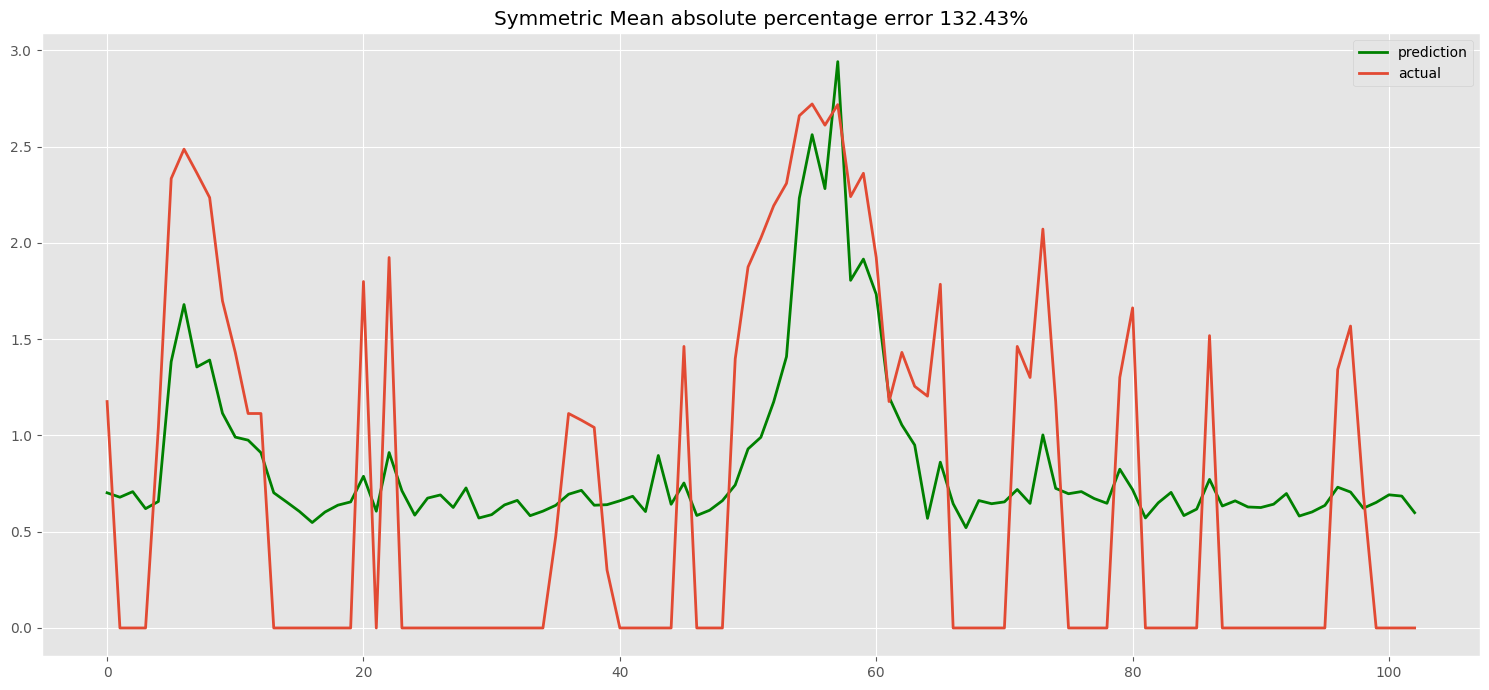

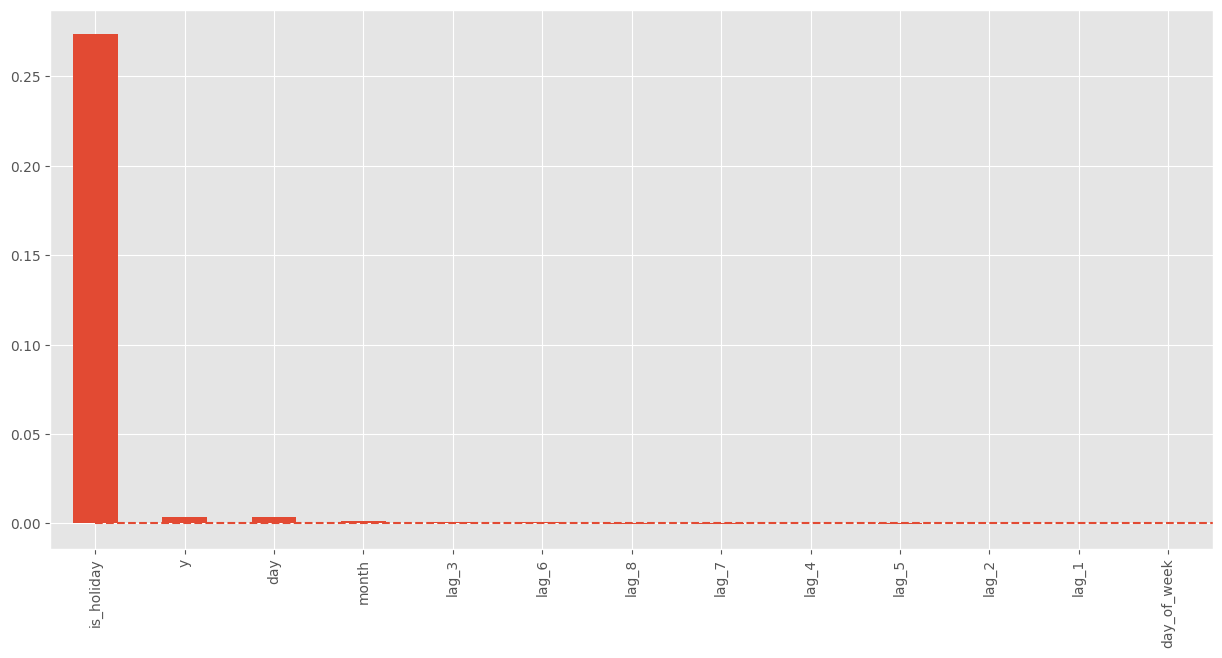



---------------------------------------
Random Forest results
Forecast Bias: 0.25%
Mean Square Error: 0.0002
Mean Absolute Error: 0.0091
Symmetric Mean Absolute Percentage Error: 79.21%


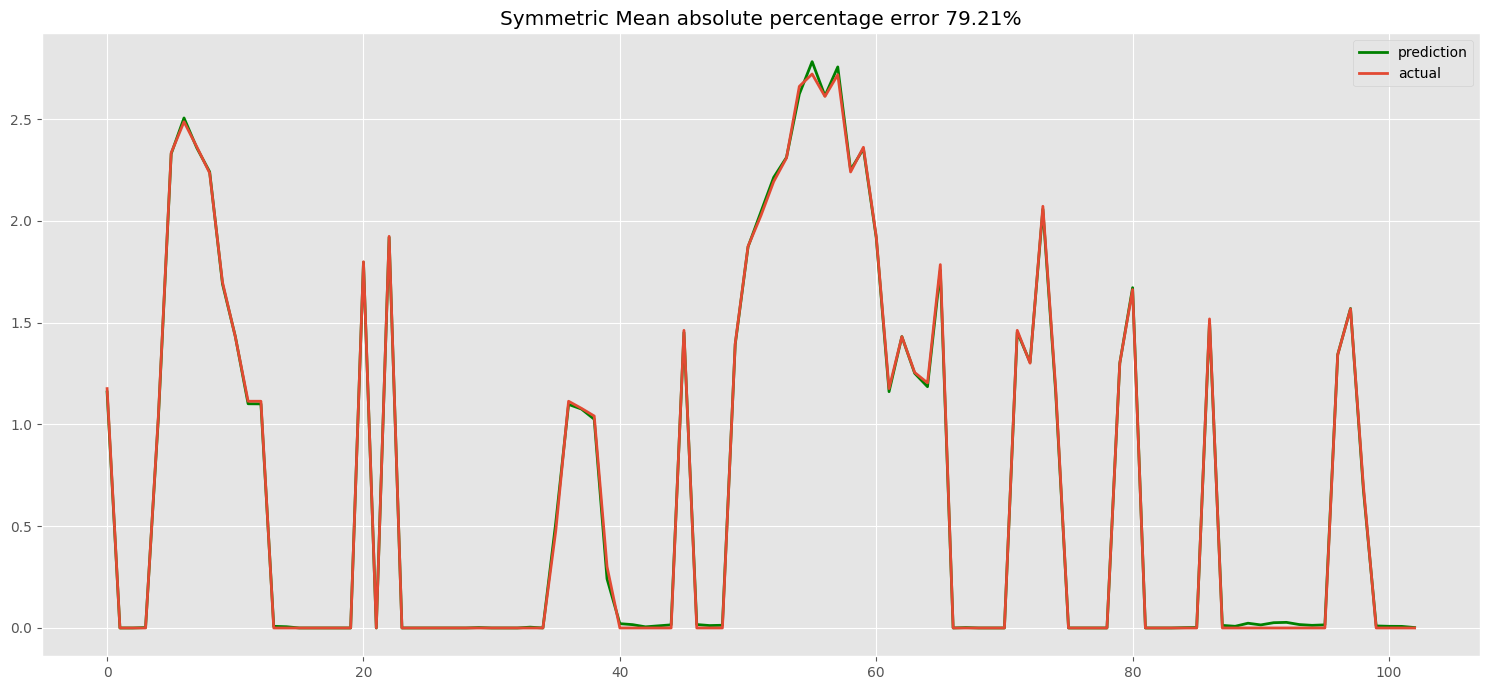

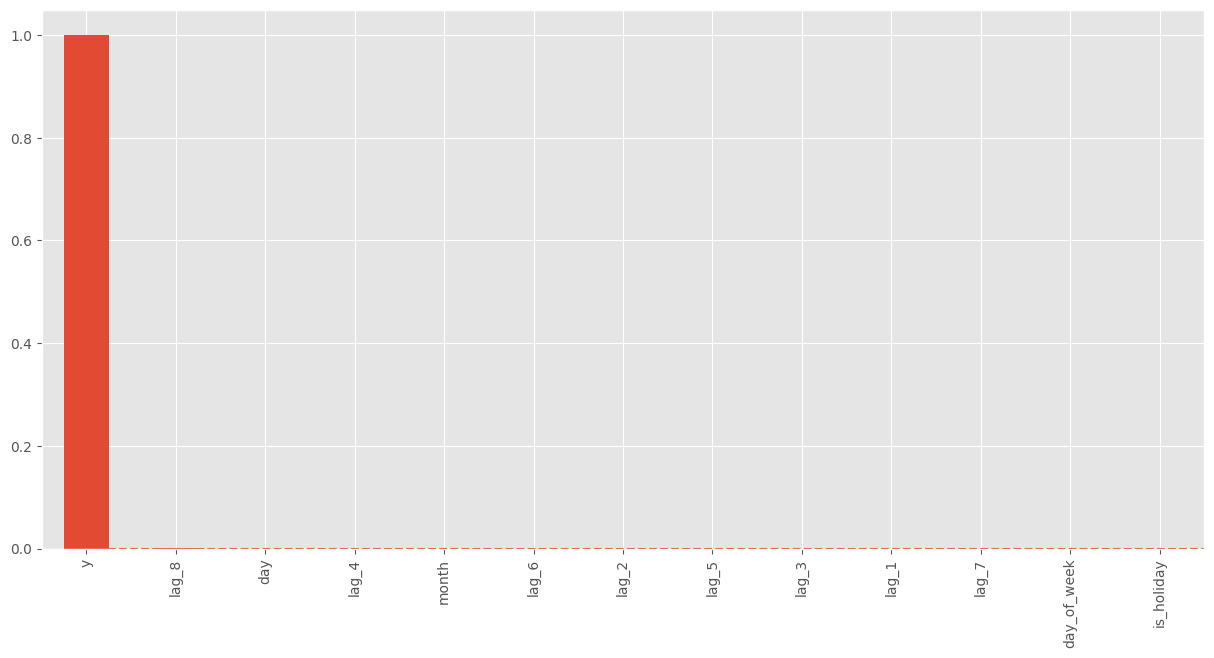



---------------------------------------
XGBoost
Forecast Bias: -0.33%
Mean Square Error: 0.0003
Mean Absolute Error: 0.0069
Symmetric Mean Absolute Percentage Error: 112.96%


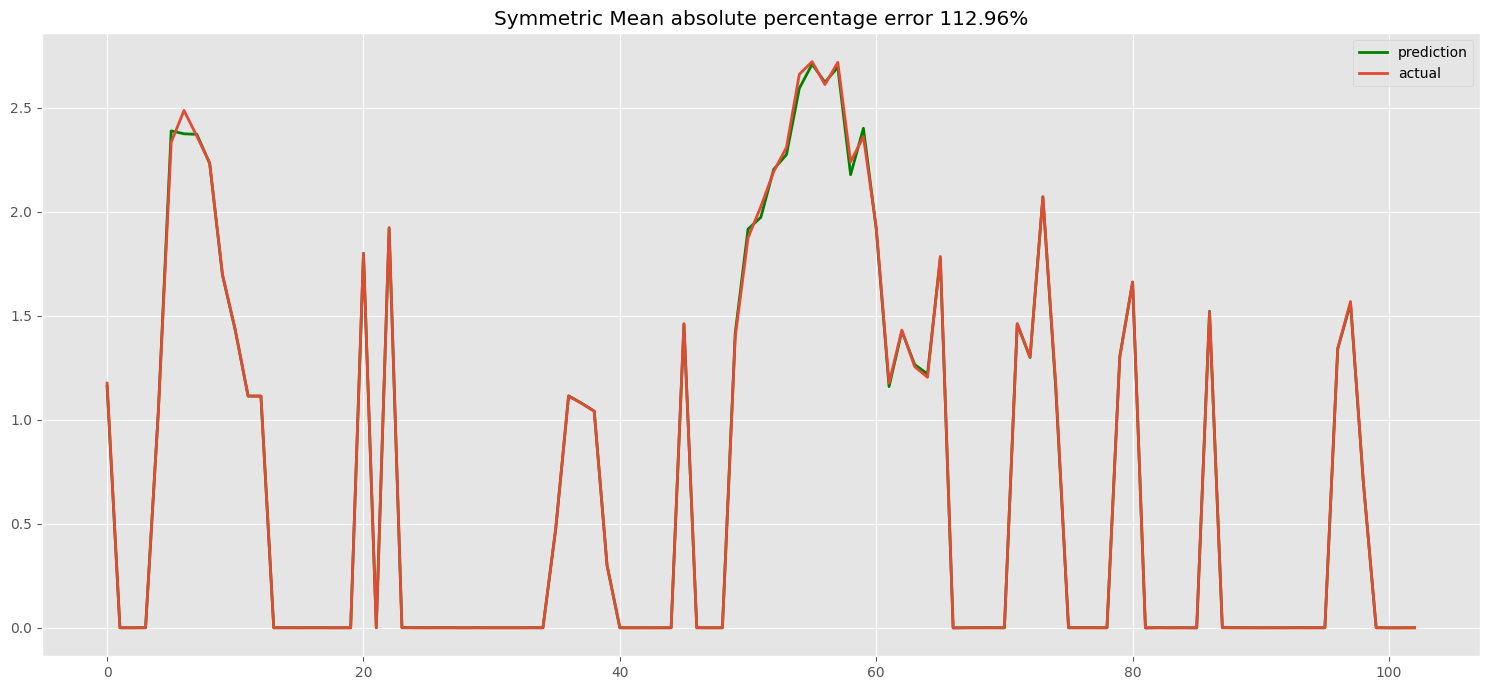

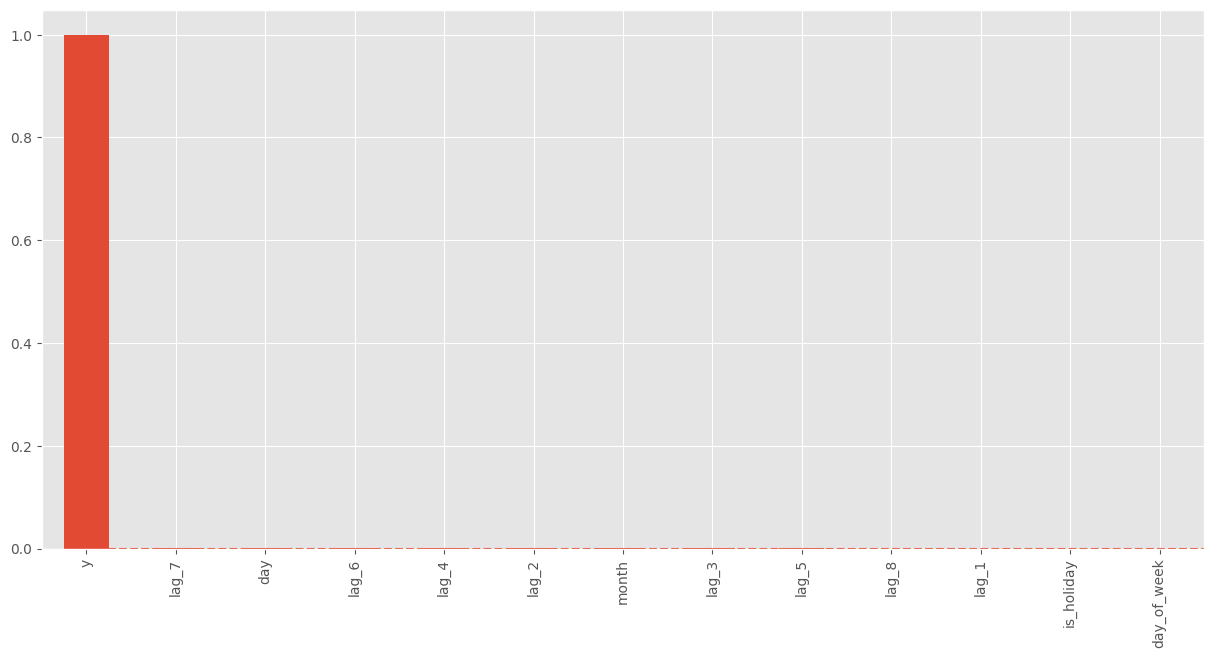

In [411]:
### Linear Regression
print("---------------------------------------")
print("Linear Regression results")
model = LinearRegression()
model = model.fit(X=X_train,
                  y=y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model, X_train=X_train)

### Random Forest
print("\n\n---------------------------------------")
print(f"Random Forest results")
model = RandomForestRegressor(n_estimators=50,
                              max_depth=50,
                              min_samples_leaf=3,)

model.fit(X_train, y_train.values.ravel())
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model,
                 X_train=X_train)

### XGBoost
print("\n\n---------------------------------------")
print("XGBoost")
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
plotModelResults(model=xgb,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)
plotCoefficients(model=xgb,
                 X_train=X_train)

Veo que el mejor resultado lo obtengo con Random Forest, y visualmente XGBoost también se acerca bastante. El que no consigue captar bien los patrones es la regresión lineal y esto se deberá a que mis datos no son tan simples y lineales como para que se puedan capturar con ese modelo.

Por los datos obtenidos en `Random Forest` veo lo siguiente:
- Según el `Forecast Bias` no hay casi sesgo, por lo que ni se subestima ni se sobreestima mucho
- Según el `MSE` veo que las predicciones son muy cercanas a los valores reales, algo que corroboro visualmente.
- El `MAE` también es bajo
- El `SMAPE` sigue alto, a lo mejor por la cantidad de 0s que hay. Puede que con algún ajuste de hiperparámetros mejorara.

## Deep Learning

In [412]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob):
        """ Inicializa una instancia de RNN.

        Args:
            input_dim (int): El número de nodos en la capa de entrada
            hidden_dim (int): El número de nodos en cada capa oculta
            layer_dim (int): El número de capas en la red
            output_dim (int): El número de nodos en la capa de salida
            dropout_prob (float): La probabilidad de dropout para las capas

        """
        super(RNNModel, self).__init__()

        # Definición del número de capas y los nodos en cada capa
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # Capas RNN
        self.rnn = nn.RNN(
            input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout_prob
        )
        # Capas Fully-Connected
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """Realiza la propagación hacia adelante.

        Args:
            x (torch.Tensor): Tensor de entrada de forma (tamaño del batch, longitud de secuencia, input_dim)

        Returns:
            torch.Tensor: Tensor de salida de forma (tamaño del bacth, output_dim)

        """
        # Inicializando el estado oculto para la primera entrada con ceros
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim,device=x.device).requires_grad_()

        # Propagación hacia adelante pasando la entrada y el estado oculto al modelo
        out, h0 = self.rnn(x, h0.detach())

        # Reorganizando las salidas en la forma (tamaño del batch, longitud de secuencia, tamaño oculto)
        # para que pueda encajar en la capa completamente conectada
        out = out[:, -1, :]

        # Convertir el estado final a nuestra forma de salida deseada (tamaño del batch, output_dim)
        out = self.fc(out)
        return out

In [413]:
class LSTMModel(nn.Module):
    """Clase LSTMModel que extiende la clase nn.Module y funciona como constructor de LSTMs.

       La clase LSTMModel inicia un módulo LSTM basado en la clase nn.Module de PyTorch.
       Tiene solo dos métodos, a saber, init() y forward(). Mientras que el método init()
       inicia el modelo con los parámetros de entrada dados, el método forward()
       define cómo se debe calcular la propagación hacia adelante.
       Dado que PyTorch define automáticamente la retropropagación, no es necesario
       definir el método de retropropagación.

       Atributos:
           hidden_dim (int): El número de nodos en cada capa oculta
           layer_dim (int): El número de capas en la red
           lstm (nn.LSTM): El modelo LSTM construido con los parámetros de entrada.
           fc (nn.Linear): La capa completamente conectada para convertir el estado final
                           de las LSTMs a nuestra forma de salida deseada.

    """
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob):
        """El método __init__ que inicia una instancia de LSTM.

        Args:
            input_dim (int): El número de nodos en la capa de entrada
            hidden_dim (int): El número de nodos en cada capa oculta
            layer_dim (int): El número de capas en la red
            output_dim (int): El número de nodos en la capa de salida
            dropout_prob (float): La probabilidad de dropout para las capas

        """
        super(LSTMModel, self).__init__()

        # Definiendo el número de capas y los nodos en cada capa
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # Capas LSTM
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout_prob
        )

        # Capa completamente conectada
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """El método forward toma el tensor de entrada x y realiza la propagación hacia adelante

        Args:
            x (torch.Tensor): El tensor de entrada de forma (tamaño del batch, longitud de secuencia, input_dim)

        Returns:
            torch.Tensor: El tensor de salida de forma (tamaño del batch, output_dim)

        """
        # Inicializando el estado oculto para la primera entrada con ceros
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        # Inicializando el estado de celda para la primera entrada con ceros
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device).requires_grad_()

        # Necesitamos desvincular porque estamos haciendo retropropagación truncada a través del tiempo (BPTT)
        # Si no lo hacemos, retrocederemos hasta el principio incluso después de pasar por otro batch
        # Propagación hacia adelante pasando la entrada, el estado oculto y el estado de celda al modelo
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        # Reorganizando las salidas en la forma de (tamaño del batch, longitud de secuencia, tamaño oculto)
        # para que pueda encajar en la capa completamente conectada
        out = out[:, -1, :]

        # Convertir el estado final a nuestra forma de salida deseada (tamaño del batch, output_dim)
        out = self.fc(out)

        return out


In [414]:
class GRUModel(nn.Module):
    """La clase GRUModel extiende la clase nn.Module y funciona como un constructor para GRUs.

       La clase GRUModel inicia un módulo GRU basado en la clase nn.Module de PyTorch.
       Tiene solo dos métodos, a saber, init() y forward(). Mientras que el método init()
       inicia el modelo con los parámetros de entrada dados, el método forward()
       define cómo se debe calcular la propagación hacia adelante.
       Dado que PyTorch define automáticamente la retropropagación, no es necesario
       definir el método de retropropagación.

       Atributos:
           hidden_dim (int): El número de nodos en cada capa oculta
           layer_dim (int): El número de capas en la red
           gru (nn.GRU): El modelo GRU construido con los parámetros de entrada.
           fc (nn.Linear): La capa completamente conectada para convertir el estado final
                           de las GRUs a nuestra forma de salida deseada.

    """
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob):
        """El método __init__ inicia una instancia de GRU.

        Args:
            input_dim (int): El número de nodos en la capa de entrada
            hidden_dim (int): El número de nodos en cada capa oculta
            layer_dim (int): El número de capas en la red
            output_dim (int): El número de nodos en la capa de salida
            dropout_prob (float): La probabilidad de dropout para las capas

        """
        super(GRUModel, self).__init__()

        # Definición del número de capas y los nodos en cada capa
        self.layer_dim = layer_dim
        self.hidden_dim = hidden_dim

        # Capas GRU
        self.gru = nn.GRU(
            input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout_prob
        )

        # Capa completamente conectada
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """El método forward toma el tensor de entrada x y realiza la propagación hacia adelante

        Args:
            x (torch.Tensor): El tensor de entrada de forma (tamaño del batch, longitud de secuencia, input_dim)

        Returns:
            torch.Tensor: El tensor de salida de forma (tamaño del batch, output_dim)

        """
        # Inicializando el estado oculto para la primera entrada con ceros
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device).requires_grad_()

        # Propagación hacia adelante pasando la entrada y el estado oculto al modelo
        out, _ = self.gru(x, h0.detach())

        # Reorganizando las salidas en la forma de (tamaño del batch, longitud de secuencia, tamaño oculto)
        # para que pueda encajar en la capa completamente conectada
        out = out[:, -1, :]

        # Convertir el estado final a nuestra forma de salida deseada (tamaño del batch, output_dim)
        out = self.fc(out)

        return out


In [415]:
def get_model(model, model_params):
    models = {
        "rnn": RNNModel,
        "lstm": LSTMModel,
        "gru": GRUModel,
    }
    return models.get(model.lower())(**model_params)

In [416]:
class Optimization:
    """La clase Optimization es una clase auxiliar que permite entrenar, validar y predecir.

    Optimization es una clase auxiliar que toma el modelo, la función de pérdida, la función de optimización
    el programador de aprendizaje (opcional), la detención anticipada (opcional) como entradas. A cambio,
    proporciona un marco para entrenar y validar los modelos, y para predecir valores futuros
    basado en los modelos.

    Atributos:
        model (RNNModel, LSTMModel, GRUModel): Clase del modelo creada para el tipo de RNN
        loss_fn (torch.nn.modules.Loss): Función de pérdida para calcular las pérdidas
        optimizer (torch.optim.Optimizer): Función de optimización para optimizar la función de pérdida
        train_losses (list[float]): Los valores de pérdida del entrenamiento
        val_losses (list[float]): Los valores de pérdida de la validación
        last_epoch (int): El número de épocas que el modelo ha sido entrenado
    """
    def __init__(self, model, loss_fn, optimizer):
        """
        Args:
            model (RNNModel, LSTMModel, GRUModel): Clase del modelo creada para el tipo de RNN
            loss_fn (torch.nn.modules.Loss): Función de pérdida para calcular las pérdidas
            optimizer (torch.optim.Optimizer): Función de optimización para optimizar la función de pérdida
        """
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.train_losses = []
        self.val_losses = []

    def train_step(self, x, y):
        """El método train_step completa un paso de entrenamiento.

        Dados los tensores de características (x) y los valores objetivo (y), el método completa
        un paso del entrenamiento. Primero, activa el modo de entrenamiento para habilitar la retropropagación.
        Después de generar valores predichos (yhat) haciendo propagación hacia adelante, calcula
        las pérdidas usando la función de pérdida. Luego, calcula los gradientes haciendo
        retropropagación y actualiza los pesos llamando a la función step().

        Args:
            x (torch.Tensor): Tensor de características para entrenar un paso
            y (torch.Tensor): Tensor de valores objetivo para calcular las pérdidas

        """
        # Establece el modelo en modo de entrenamiento
        self.model.train()

        # Realiza predicciones
        yhat = self.model(x)

         # Calcula la pérdida
        loss = self.loss_fn(y, yhat)

        # Calcula los gradientes
        loss.backward()

        # Actualiza los parámetros y pone a cero los gradientes
        self.optimizer.step()
        self.optimizer.zero_grad()

        # Devuelve la pérdida
        return loss.item()

    def train(self, train_loader, val_loader, batch_size=64, n_epochs=50, n_features=1):
        """El método train realiza el entrenamiento del modelo

        El método toma los DataLoaders para los conjuntos de datos de entrenamiento y validación, el tamaño de batch para
        el entrenamiento en mini-batches, el número de épocas para entrenar y el número de características como entradas.
        Luego, lleva a cabo el entrenamiento llamando iterativamente al método train_step durante
        n_epochs veces. Si la detención anticipada está habilitada, entonces comprueba la condición de parada
        para decidir si el entrenamiento debe detenerse antes de n_epochs pasos. Finalmente, guarda
        el modelo en una ruta de archivo designada.

        Args:
            train_loader (torch.utils.data.DataLoader): DataLoader que almacena los datos de entrenamiento
            val_loader (torch.utils.data.DataLoader): DataLoader que almacena los datos de validación
            batch_size (int): Tamaño de batch para el entrenamiento en mini-batches
            n_epochs (int): Número de épocas, es decir, pasos de entrenamiento, para entrenar
            n_features (int): Número de columnas de características

        """
        model_path = f'{self.model}_{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}'

        for epoch in range(1, n_epochs + 1):
            batch_losses = []
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.view([x_batch.size(0), -1, n_features])
                y_batch = y_batch
                loss = self.train_step(x_batch, y_batch)
                batch_losses.append(loss)
            training_loss = np.mean(batch_losses)
            self.train_losses.append(training_loss)

            with torch.no_grad():
                batch_val_losses = []
                for x_val, y_val in val_loader:
                    x_val = x_val.view([x_batch.size(0), -1, n_features])
                    y_val = y_val
                    self.model.eval()
                    yhat = self.model(x_val)
                    val_loss = self.loss_fn(y_val, yhat).item()
                    batch_val_losses.append(val_loss)
                validation_loss = np.mean(batch_val_losses)
                self.val_losses.append(validation_loss)

            if (epoch <= 10) | (epoch % 50 == 0):
                print(
                    f"[{epoch}/{n_epochs}] Training loss: {training_loss:.4f}\t Validation loss: {validation_loss:.4f}"
                )

        torch.save(self.model.state_dict(), model_path)

    def evaluate(self, test_loader, batch_size=1, n_features=1):
        """El método evaluate realiza la evaluación del modelo

        El método toma DataLoaders para el conjunto de datos de prueba, el tamaño de batch para la prueba en mini-batches,
        y el número de características como entradas. Similar a la validación del modelo, itera
        predice los valores objetivo y calcula las pérdidas. Luego, devuelve dos listas que
        contienen las predicciones y los valores reales.

        Nota:
            Este método asume que la predicción del paso anterior está disponible en
            el momento de la predicción, y solo hace una predicción de un paso hacia el futuro.

        Args:
            test_loader (torch.utils.data.DataLoader): DataLoader que almacena los datos de prueba
            batch_size (int): Tamaño de batch para la prueba en mini-batches
            n_features (int): Número de columnas de características

        Returns:
            list[float]: Los valores predichos por el modelo
            list[float]: Los valores reales en el conjunto de prueba.

        """
        with torch.no_grad():
            predictions = []
            values = []
            for x_test, y_test in test_loader:
                x_test = x_test.view([batch_size, -1, n_features])
                y_test = y_test
                self.model.eval()
                yhat = self.model(x_test)
                yhat=yhat.cpu().data.numpy()
                predictions.append(yhat)
                y_test=y_test.cpu().data.numpy()
                values.append(y_test)

        return predictions, values

    def plot_losses(self):
        """El método plot_losses traza los valores de pérdida calculados
        para entrenamiento y validación
        """
        plt.style.use('ggplot')
        plt.figure(figsize=(10,5))
        plt.plot(self.train_losses, label="Training loss")
        plt.plot(self.val_losses, label="Validation loss")
        plt.legend()
        plt.title("Losses")
        plt.show()
        plt.close()

In [417]:
def General_Settings(model_name):

        input_dim = len(X_train.columns)
        output_dim = 1
        hidden_dim = 64
        layer_dim = 2
        batch_size = 8
        dropout = 0.1
        n_epochs = 50
        learning_rate = 1e-3
        weight_decay = 1e-5

        model_params = {'input_dim': input_dim,
                        'hidden_dim' : hidden_dim,
                        'layer_dim' : layer_dim,
                        'output_dim' : output_dim,
                        'dropout_prob' : dropout}
        model = get_model(model_name, model_params)
        # He cambiado la función de pérdida para que fuera menos fuerte
        loss_fn = nn.SmoothL1Loss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        opt = Optimization(model=model, loss_fn=loss_fn, optimizer=optimizer)
        opt.train(train_loader, val_loader, batch_size=batch_size, n_epochs=n_epochs, n_features=input_dim)
        opt.plot_losses()

        predictions, values = opt.evaluate(
            test_loader_one,
            batch_size=1,
            n_features=input_dim
        )
        return predictions,values


In [418]:
def inverse_transform(scaler, df, columns):
    for col in columns:
        df[col] = scaler.inverse_transform(df[col])
    return df

def antilog(data):
    # Revierto la transformación logarítmica
    data_antilog = 10**data - 1
    # Me aseguro de que los valores no sean negativos
    data_antilog = data_antilog.clip(lower=0)
    return data_antilog


def format_predictions(predictions, values, df_test, scaler, col_name="y"):
    vals = np.concatenate(values, axis=0).ravel()
    preds = np.concatenate(predictions, axis=0).ravel()

    df_result = pd.DataFrame(data={col_name: vals, "prediction": preds}, index=df_test.head(len(vals)).index)
    df_result = df_result.sort_index()

    # Desescalo ambas columnas ('y' y prediction)
    df_result[[col_name, "prediction"]] = scaler.inverse_transform(df_result[[col_name, "prediction"]])

    # Aplico el antilog a ambas columnas ('y' y prediction)
    df_result[col_name] = antilog(df_result[col_name])
    df_result["prediction"] = antilog(df_result["prediction"])

    # Clip para no tener negativos
    df_result["prediction"] = df_result["prediction"].clip(lower=0)

    return df_result


In [419]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(df, col_name="y"):
    result_metrics = {'mae' : mean_absolute_error(df[col_name], df.prediction),
                      'rmse' : mean_squared_error(df[col_name], df.prediction) ** 0.5,
                      'r2' : r2_score(df[col_name], df.prediction)}

    print("Mean Absolute Error:       ", result_metrics["mae"])
    print("Root Mean Squared Error:   ", result_metrics["rmse"])
    print("R^2 Score:                 ", result_metrics["r2"])
    return result_metrics

In [420]:
def build_baseline_model(df, test_ratio, target_col):
    X, y = feature_label_split(df, target_col)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, shuffle=False
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    result = pd.DataFrame(y_test)
    result["prediction"] = prediction
    result = result.sort_index()

    return result

In [421]:
plt.style.use('ggplot')

def plot_predictions(df_result, df_baseline):
    data = []

    value = go.Scatter(
        x=df_result.index,
        y=df_result.y,
        mode="lines",
        name="values",
        marker=dict(),
        text=df_result.index,
        line=dict(color="rgba(0,0,0, 0.3)"),
    )
    data.append(value)

    baseline = go.Scatter(
        x=df_baseline.index,
        y=df_baseline.prediction,
        mode="lines",
        line={"dash": "dot"},
        name='linear regression',
        marker=dict(),
        text=df_baseline.index,
        opacity=0.8,
    )
    data.append(baseline)

    prediction = go.Scatter(
        x=df_result.index,
        y=df_result.prediction,
        mode="lines",
        line={"dash": "dot"},
        name='predictions',
        marker=dict(),
        text=df_result.index,
        opacity=0.8,
    )
    data.append(prediction)

    layout = dict(
        title="Predictions vs Actual Values for the dataset",
        xaxis=dict(title="Time", ticklen=5, zeroline=False),
        yaxis=dict(title="Value", ticklen=5, zeroline=False),
    )

    fig = go.Figure(data=data, layout=layout)
    fig.show()

[1/50] Training loss: 0.0726	 Validation loss: 0.0513
[2/50] Training loss: 0.0416	 Validation loss: 0.0491
[3/50] Training loss: 0.0379	 Validation loss: 0.0460
[4/50] Training loss: 0.0334	 Validation loss: 0.0434
[5/50] Training loss: 0.0298	 Validation loss: 0.0405
[6/50] Training loss: 0.0258	 Validation loss: 0.0384
[7/50] Training loss: 0.0250	 Validation loss: 0.0354
[8/50] Training loss: 0.0228	 Validation loss: 0.0335
[9/50] Training loss: 0.0203	 Validation loss: 0.0312
[10/50] Training loss: 0.0199	 Validation loss: 0.0290
[50/50] Training loss: 0.0033	 Validation loss: 0.0068


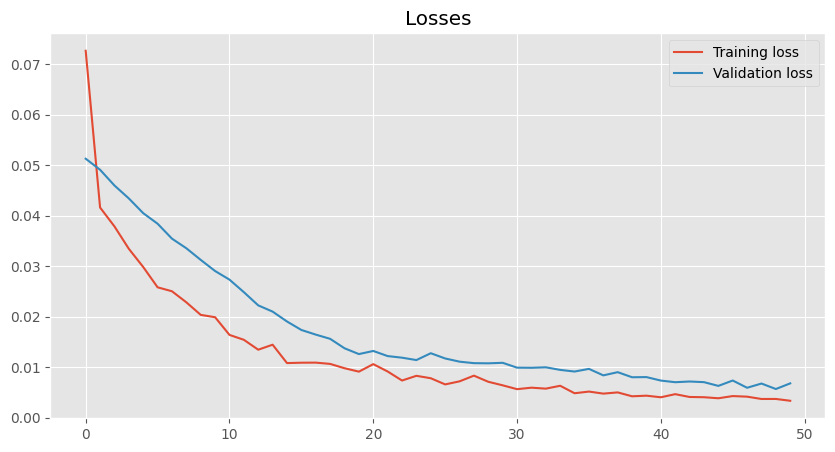

Mean Absolute Error:        14.538827896118164
Root Mean Squared Error:    43.61310614188985
R^2 Score:                  0.8290621042251587
{'mae': 14.538827896118164, 'rmse': 43.61310614188985, 'r2': 0.8290621042251587}
Mean Absolute Error:        33.61150643047033
Root Mean Squared Error:    49.156754775913114
R^2 Score:                  0.7828445365657278
{'mae': 33.61150643047033, 'rmse': 49.156754775913114, 'r2': 0.7828445365657278}


In [422]:
# model_name=Enter model name 'lstm','rnn','gru'
model_name='rnn'
predictions, values=General_Settings(model_name)
df_result=format_predictions(predictions, values, X_test, scaler)
print(calculate_metrics(df_result))
df_baseline = build_baseline_model(df_features, 0.2, 'y')
print(calculate_metrics(df_baseline))
plot_predictions(df_result, df_baseline)

[1/50] Training loss: 0.1320	 Validation loss: 0.0874
[2/50] Training loss: 0.0815	 Validation loss: 0.0651
[3/50] Training loss: 0.0499	 Validation loss: 0.0551
[4/50] Training loss: 0.0365	 Validation loss: 0.0500
[5/50] Training loss: 0.0301	 Validation loss: 0.0462
[6/50] Training loss: 0.0262	 Validation loss: 0.0421
[7/50] Training loss: 0.0226	 Validation loss: 0.0372
[8/50] Training loss: 0.0188	 Validation loss: 0.0334
[9/50] Training loss: 0.0160	 Validation loss: 0.0301
[10/50] Training loss: 0.0141	 Validation loss: 0.0270
[50/50] Training loss: 0.0026	 Validation loss: 0.0095


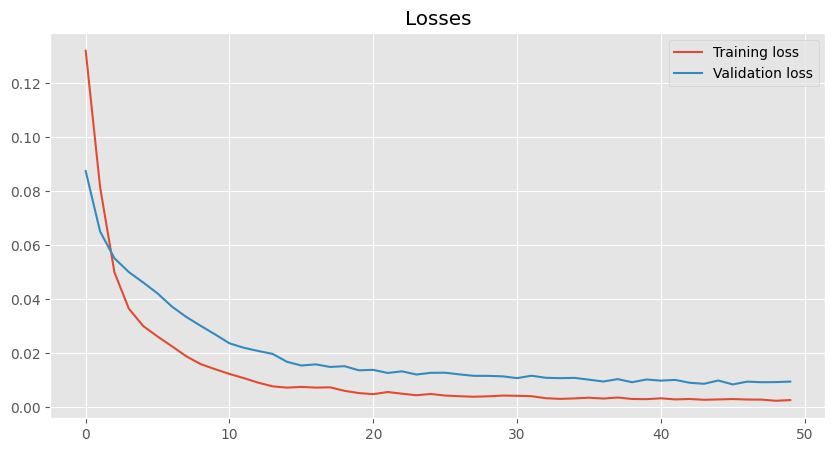

Mean Absolute Error:        5.218434810638428
Root Mean Squared Error:    10.086312308464711
R^2 Score:                  0.9908574223518372
{'mae': 5.218434810638428, 'rmse': 10.086312308464711, 'r2': 0.9908574223518372}
Mean Absolute Error:        33.61150643047033
Root Mean Squared Error:    49.156754775913114
R^2 Score:                  0.7828445365657278
{'mae': 33.61150643047033, 'rmse': 49.156754775913114, 'r2': 0.7828445365657278}


In [423]:
model_name='lstm'
predictions, values=General_Settings(model_name)
df_result=format_predictions(predictions, values, X_test, scaler)
print(calculate_metrics(df_result))
df_baseline = build_baseline_model(df_features, 0.2, 'y')
print(calculate_metrics(df_baseline))
plot_predictions(df_result, df_baseline)

[1/50] Training loss: 0.1076	 Validation loss: 0.0694
[2/50] Training loss: 0.0540	 Validation loss: 0.0540
[3/50] Training loss: 0.0396	 Validation loss: 0.0478
[4/50] Training loss: 0.0320	 Validation loss: 0.0437
[5/50] Training loss: 0.0278	 Validation loss: 0.0404
[6/50] Training loss: 0.0243	 Validation loss: 0.0367
[7/50] Training loss: 0.0211	 Validation loss: 0.0344
[8/50] Training loss: 0.0201	 Validation loss: 0.0311
[9/50] Training loss: 0.0166	 Validation loss: 0.0287
[10/50] Training loss: 0.0151	 Validation loss: 0.0268
[50/50] Training loss: 0.0030	 Validation loss: 0.0081


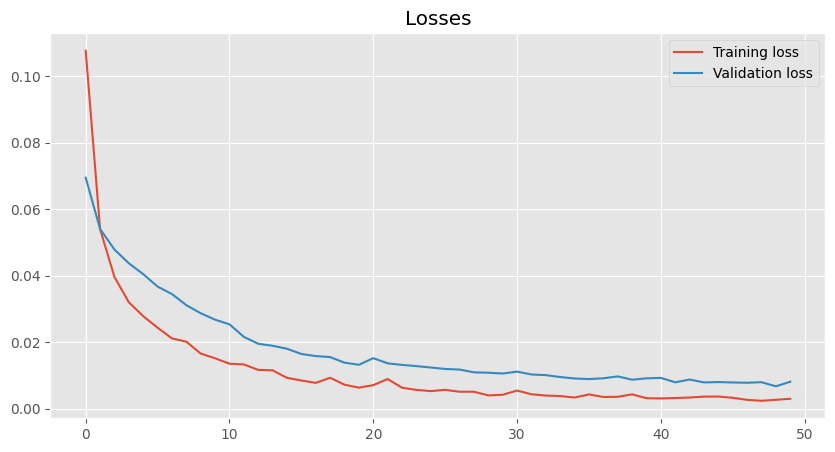

Mean Absolute Error:        7.126347541809082
Root Mean Squared Error:    16.309296859843467
R^2 Score:                  0.9760957956314087
{'mae': 7.126347541809082, 'rmse': 16.309296859843467, 'r2': 0.9760957956314087}
Mean Absolute Error:        33.61150643047033
Root Mean Squared Error:    49.156754775913114
R^2 Score:                  0.7828445365657278
{'mae': 33.61150643047033, 'rmse': 49.156754775913114, 'r2': 0.7828445365657278}


In [424]:
# model_name=Enter model name 'lstm','rnn','gru'
model_name='gru'
predictions, values=General_Settings(model_name)
df_result=format_predictions(predictions, values, X_test, scaler)
print(calculate_metrics(df_result))
df_baseline = build_baseline_model(df_features, 0.2, 'y')
print(calculate_metrics(df_baseline))
plot_predictions(df_result, df_baseline)

Veo que el modelo de DL que mejor se adapta es el LSTM ya que:
- Tiene el MAE más bajo
- Tiene el RMSE más bajo
- Tiene el R² más alto, por lo que tiene bastante capacidad de ajuste

Creo que esto se debe a que este modelo está diseñado para capturar patrones secuenciales complejos y dependecias a largo plazo, características clave en mi serie temporal semanal, que presenta patrones estacionales y semanales.

Por último creo que si tuviera que elegir entre el modelo que mejor se adapta de ML, el `Random Forest` y el modelo que mejor se adapta de DL, el `LSTM`, me quedaría con el LSTM por estar diseñado específicamente para series temporales y por su alto valor de R² (alta capacidad para explicar la variablidad).